In [3]:
!pip install scikit-learn matplotlib numpy

In [4]:
!pip install mediapipe --quiet --ignore-requires-python
import mediapipe as mp
print(mp.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.0 MB/s eta 0:00:00
0.10.33


In [5]:
import mediapipe as mp
print("MediaPipe version:", mp.__version__)

MediaPipe version: 0.10.33


✅ Dataset: 900 samples | 6 gestures
Train: 720 | Test: 180

Training...

✅ Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00        30
          ok       1.00      1.00      1.00        30
        palm       1.00      1.00      1.00        30
       peace       1.00      1.00      1.00        30
       point       1.00      1.00      1.00        30
   thumbs_up       1.00      1.00      1.00        30

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



/tmp/ipykernel_9661/3567721892.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(unique, rotation=30, ha='right')


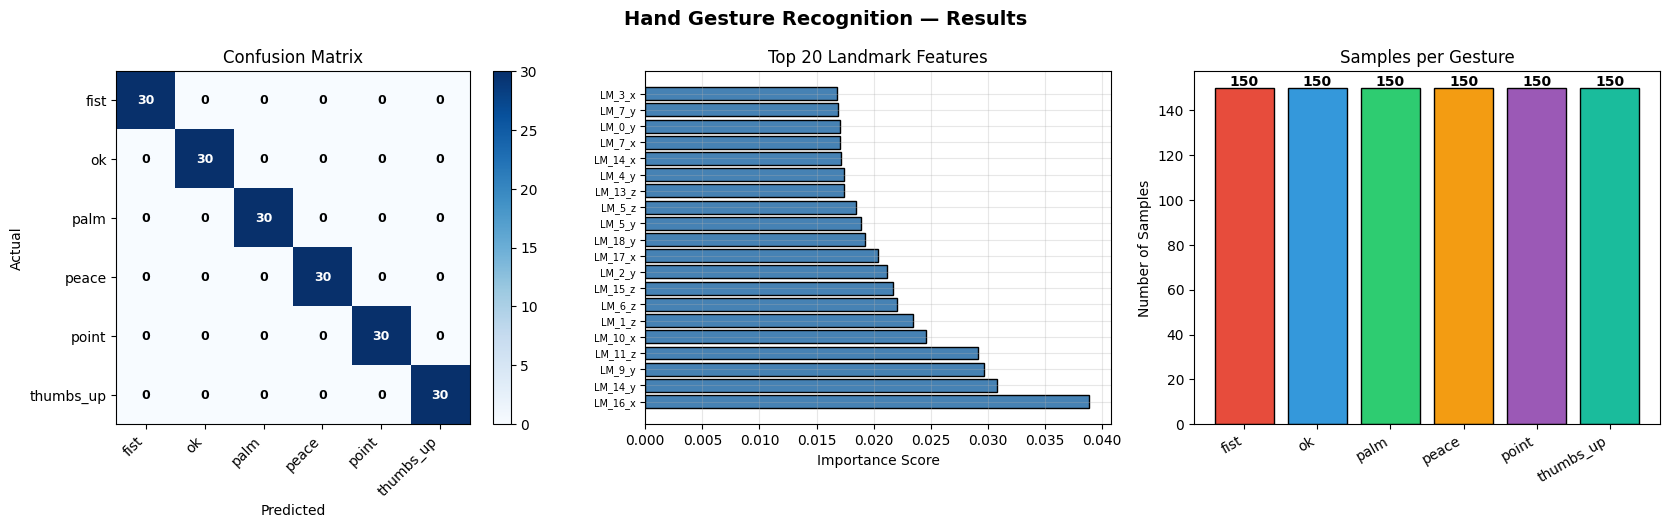


✅ Done!


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ─────────────────────────────────────────────
# 1. Simulate Hand Landmark Data
#    21 landmarks x 3 coords (x,y,z) = 63 features
# ─────────────────────────────────────────────
GESTURES = ['palm', 'fist', 'thumbs_up', 'peace', 'ok', 'point']
np.random.seed(42)
n_per_class = 150

X, y = [], []
for i, gesture in enumerate(GESTURES):
    samples = np.random.randn(n_per_class, 63) + i * 1.5
    X.append(samples)
    y.extend([gesture] * n_per_class)

X = np.vstack(X)
y = np.array(y)
print(f"✅ Dataset: {X.shape[0]} samples | {len(GESTURES)} gestures")

# ─────────────────────────────────────────────
# 2. Encode & Split
# ─────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ─────────────────────────────────────────────
# 3. Train Random Forest
# ─────────────────────────────────────────────
print("\nTraining...")
model = RandomForestClassifier(n_estimators=200, max_depth=15,
                                random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# ─────────────────────────────────────────────
# 4. Evaluate
# ─────────────────────────────────────────────
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ─────────────────────────────────────────────
# 5. Visualizations
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Hand Gesture Recognition — Results", fontsize=14, fontweight='bold')

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=9,
                fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax)

# Feature Importance
ax = axes[1]
importances = model.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
ax.barh(range(20), importances[top_idx], color='steelblue', edgecolor='black')
ax.set_yticks(range(20))
ax.set_yticklabels([f'LM_{i//3}_{["x","y","z"][i%3]}' for i in top_idx], fontsize=7)
ax.set_xlabel("Importance Score")
ax.set_title("Top 20 Landmark Features")
ax.grid(True, alpha=0.3)

# Samples per Gesture
ax = axes[2]
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
unique, counts = np.unique(y, return_counts=True)
bars = ax.bar(unique, counts, color=colors, edgecolor='black')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()+1, str(val), ha='center', fontweight='bold')
ax.set_ylabel("Number of Samples")
ax.set_title("Samples per Gesture")
ax.set_xticklabels(unique, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('gesture_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Done!")